# Premier League Dataset with pandas

We have cleaned this data and uploaded it to GitHub, now we will use pandas to download it to our file here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Getting the url code

In [ ]:
url = 'https://raw.githubusercontent.com/kkathait/D501_Final_Project/refs/heads/main/combined_data.csv'

df_premier = pd.read_csv(url)

# Converting our data.

Our data does not contain a standard Win - Loss - Tie record for our team, so I created one

In [8]:
teams = sorted(set(df_premier["HomeTeam"]) | set(df_premier["AwayTeam"]))

records = []

for team in teams:
    home_games = df_premier[df_premier["HomeTeam"] == team]
    
    home_wins = (home_games["FTR"] == "H").sum()
    home_losses = (home_games["FTR"] == "A").sum()
    home_draws = (home_games["FTR"] == "D").sum()
    
    away_games = df_premier[df_premier["AwayTeam"] == team]
    
    away_wins = (away_games["FTR"] == "A").sum()
    away_losses = (away_games["FTR"] == "H").sum()
    away_draws = (away_games["FTR"] == "D").sum()
    
    records.append({
        "Team": team,
        "Wins": home_wins + away_wins,
        "Losses": home_losses + away_losses,
        "Draws": home_draws + away_draws
    })

standings = pd.DataFrame(records)

standings = standings.sort_values("Wins", ascending = False)

standings

,Team,Wins,Losses,Draws
12,Liverpool,73,11,18
13,Man City,73,15,14
6,Chelsea,52,24,26
19,Tottenham,51,31,20
11,Leicester,49,32,21
0,Arsenal,47,32,23
14,Man United,47,26,29
22,West Ham,41,39,22
8,Everton,38,44,20
1,Aston Villa,36,49,17


# Data Visualization
Let us look at how the data looks with some graphs

# Team Records

First we want to make a stacked bar graph and a grouped bar graph to show team records

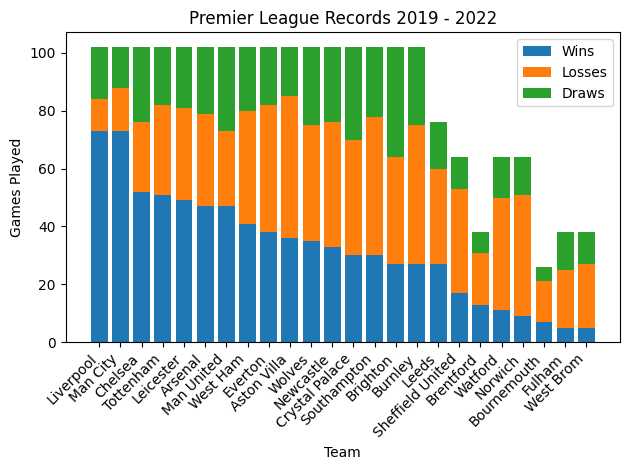

In [13]:
plt.bar(
    standings["Team"],
    standings["Wins"],
    label="Wins"
)

plt.bar(
    standings["Team"],
    standings["Losses"],
    bottom=standings["Wins"],
    label="Losses"
)

plt.bar(
    standings["Team"],
    standings["Draws"],
    bottom=standings["Wins"] + standings["Losses"],
    label="Draws"
)
plt.xlabel("Team")
plt.ylabel("Games Played")
plt.title("Premier League Records 2019 - 2022")
plt.xticks(x, standings["Team"], rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()

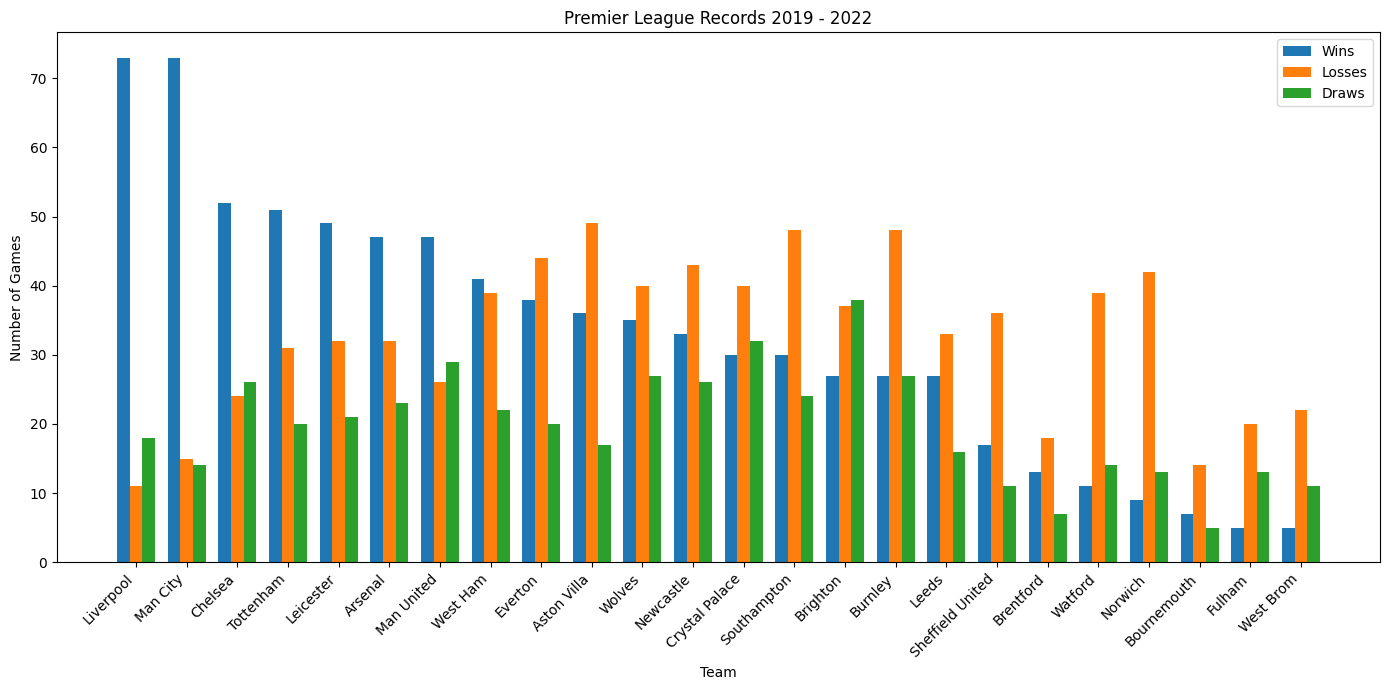

In [16]:
x = np.arange(len(standings["Team"]))
width = 0.25

plt.figure(figsize=(14, 7))

plt.bar(x - width, standings["Wins"], width, label="Wins")
plt.bar(x, standings["Losses"], width, label="Losses")
plt.bar(x + width, standings["Draws"], width, label="Draws")

plt.xlabel("Team")
plt.ylabel("Number of Games")
plt.title("Premier League Records 2019 - 2022")
plt.xticks(x, standings["Team"], rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()

# Goals

In [29]:
for team in teams:
    # Home games
    home_games = df_premier[df_premier["HomeTeam"] == team]
    
    home_goals_for = home_games["FTHG"].sum()
    home_goals_against = home_games["FTAG"].sum()
    
    # Away games
    away_games = df_premier[df_premier["AwayTeam"] == team]
    
    away_goals_for = away_games["FTAG"].sum()
    away_goals_against = away_games["FTHG"].sum()
    
    records.append({
        "Team": team,
        "Goals For": home_goals_for + away_goals_for,
        "Goals Against": home_goals_against + away_goals_against
    })

goals_table = pd.DataFrame(records)

goals_table["Goal Difference"] = (
    goals_table["Goals For"] - goals_table["Goals Against"]
)

goals_table = goals_table.sort_values(
    "Goal Difference",
    ascending=False
)

goals_table

,Team,Goals For,Goals Against,Goal Difference
13,Man City,249,87,162
37,Man City,249,87,162
36,Liverpool,223,83,140
12,Liverpool,223,83,140
6,Chelsea,177,105,72
30,Chelsea,177,105,72
19,Tottenham,180,119,61
43,Tottenham,180,119,61
35,Leicester,184,135,49
11,Leicester,184,135,49


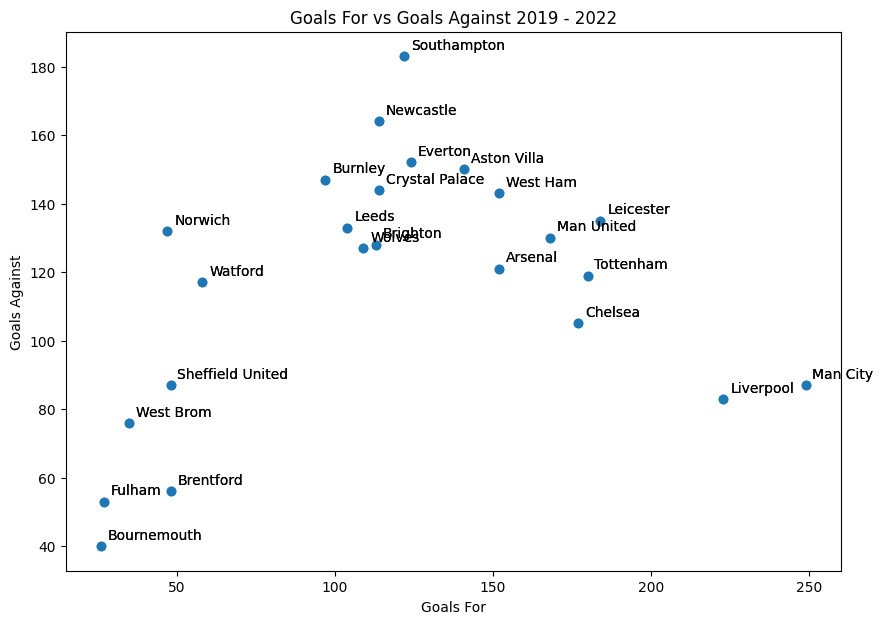

In [30]:
plt.figure(figsize=(10, 7))

plt.scatter(
    goals_table["Goals For"],
    goals_table["Goals Against"]
)

for _, row in goals_table.iterrows():
    plt.annotate(
        row["Team"],
        (row["Goals For"], row["Goals Against"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Goals For")
plt.ylabel("Goals Against")
plt.title("Goals For vs Goals Against 2019 - 2022")

plt.show()

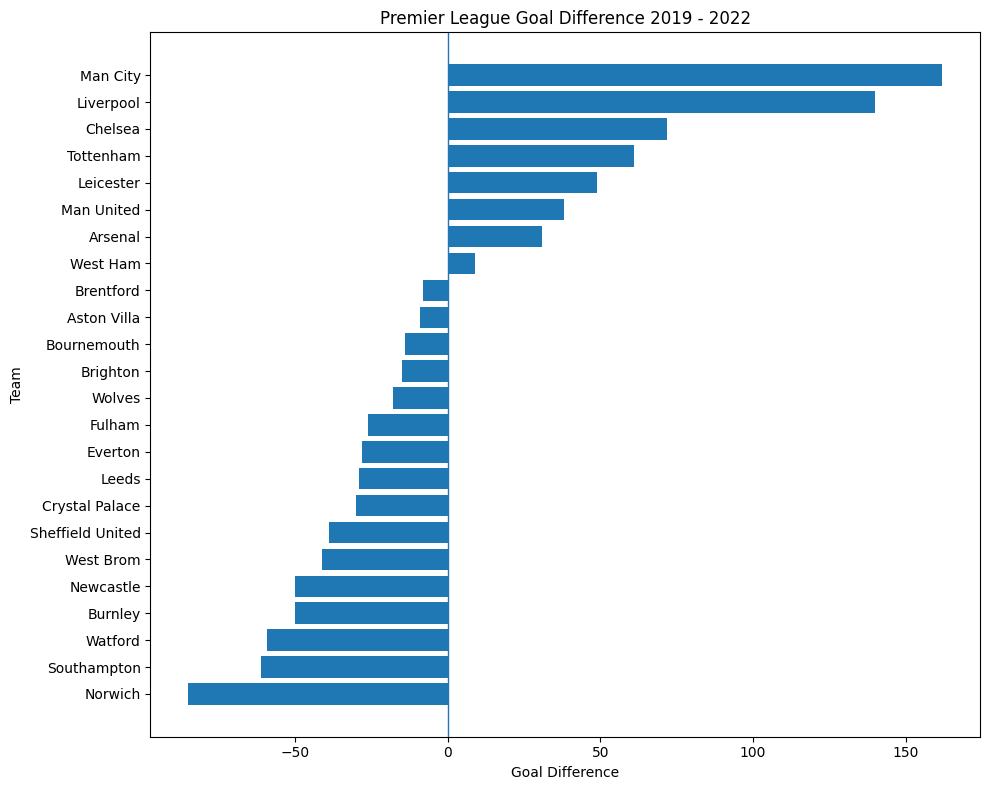

In [31]:
goals_table = goals_table.sort_values("Goal Difference")

plt.figure(figsize=(10, 8))

plt.barh(
    goals_table["Team"],
    goals_table["Goal Difference"]
)

plt.xlabel("Goal Difference")
plt.ylabel("Team")
plt.title("Premier League Goal Difference 2019 - 2022")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()